In [1]:
import os
import numpy as np
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from biosppy.signals.ecg import engzee_segmenter  # Pan-Tompkins implementation
import matplotlib.pyplot as plt

# =============================================================================
# 0. Data Loading: Define Functions to Load Real and Fake ECG Data
# =============================================================================

# Define dataset directories
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/combined_fake_ecgs"

# Additional directories for real data (each will provide 50 random files)
ADDITIONAL_REAL_DIRS = [
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/cnn_fake",
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/pulse2pulse_fake",
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/timegan_fake",
    "C:/Users/M2-Winterfell/Downloads/pulse2pulse_150k/from_006_chkp_2500_150k"
]

# Updated function to load and extract Lead I from a single .asc file
def load_lead_I_from_asc(file_path):
    try:
        # Load the .asc file (assuming it's space or tab-delimited)
        ecg_data = np.loadtxt(file_path)
        # If the file has multiple columns, extract the first column; otherwise, use the data as is.
        if ecg_data.ndim > 1 and ecg_data.shape[1] > 1:
            lead_I = ecg_data[:, 0]
        else:
            lead_I = ecg_data
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Function to load a specified number of sequentially named .asc files from a directory.
def load_sequential_lead_I_from_directory(data_dir, n):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Function to load a specified number of random .asc files from a directory.
def load_random_lead_I_from_directory(data_dir, n):
    # List all .asc files in the directory
    all_files = [f for f in os.listdir(data_dir) if f.endswith('.asc')]
    if len(all_files) < n:
        print(f"Warning: Requested {n} files but only found {len(all_files)} in {data_dir}.")
        selected_files = all_files
    else:
        selected_files = random.sample(all_files, n)
    
    lead_I_list = []
    for file_name in tqdm(selected_files, desc=f"Randomly loading Lead I from {os.path.basename(data_dir)}", unit='file'):
        file_path = os.path.join(data_dir, file_name)
        lead_I = load_lead_I_from_asc(file_path)
        if lead_I is not None:
            lead_I_list.append(lead_I)
    return np.array(lead_I_list)

# --------------------------
# Loading Real Data (Total = 2000 files)
# --------------------------
# 1. Load 1800 sequential files from the real_ecgs folder.
lead_I_real_primary = load_sequential_lead_I_from_directory(DATA_DIR_REAL, 1800)

# 2. Load 200 additional files by randomly selecting 50 files from each of the 4 additional directories.
lead_I_real_additional = []
for additional_dir in ADDITIONAL_REAL_DIRS:
    data = load_random_lead_I_from_directory(additional_dir, 50)
    lead_I_real_additional.append(data)

# Concatenate additional real data from all extra directories
lead_I_real_additional = np.concatenate(lead_I_real_additional, axis=0)

# Combine the primary and additional real data
lead_I_real = np.concatenate([lead_I_real_primary, lead_I_real_additional], axis=0)

# --------------------------
# Loading Fake Data (2000 sequential files)
# --------------------------
lead_I_fake = load_sequential_lead_I_from_directory(DATA_DIR_FAKE, 2000)

# Check if data was loaded successfully
if lead_I_fake.size > 0 and lead_I_real.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")

Randomly loading Lead I from timegan_fake: 100%|██████████| 50/50 [00:00<00:00, 58.77file/s]
Randomly loading Lead I from from_006_chkp_2500_150k: 100%|██████████| 50/50 [00:00<00:00, 52.08file/s]
Loading Lead I from combined_fake_ecgs: 100%|██████████| 2000/2000 [00:26<00:00, 76.72file/s]

Total Lead I records loaded from real data: 2000
Total Lead I records loaded from fake data: 2000



Extracting features using Pan-Tompkins algorithm...
Feature matrix shape: (4000, 10)

Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale'}

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.89      0.93       400
   Synthetic       0.90      0.97      0.94       400

    accuracy                           0.93       800
   macro avg       0.94      0.93      0.93       800
weighted avg       0.94      0.93      0.93       800

AUC-ROC: 0.952


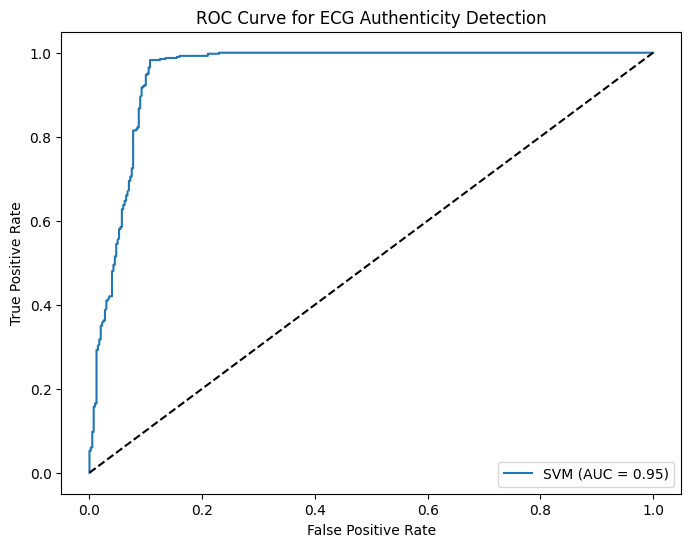

In [2]:

# =============================================================================
# 1. Prepare Labels and Combine the Data
# =============================================================================
# Use the number of records loaded to create labels:
n_real = lead_I_real.shape[0]
n_fake = lead_I_fake.shape[0]
# Label 0 for Real, 1 for Synthetic/Fake
y = np.concatenate([np.zeros(n_real), np.ones(n_fake)])

# Combine the real and fake signals into one dataset
lead_I_data = np.concatenate([lead_I_real, lead_I_fake])

# =============================================================================
# 2. Enhanced Feature Extraction using Pan-Tompkins
# =============================================================================
def extract_ecg_features(signal, sampling_rate=500):
    """
    Extract a set of ECG features including:
      - Time-domain features (mean, std, peak-to-peak, IQR)
      - Frequency-domain features (mean FFT power, dominant frequency)
      - Heart rate variability & morphological features using Pan-Tompkins R-peak detection
    """
    features = []
    
    # Time-domain features
    features.append(np.mean(signal))          # Mean amplitude
    features.append(np.std(signal))           # Standard deviation
    features.append(np.ptp(signal))           # Peak-to-peak amplitude
    features.append(np.percentile(signal, 75) - np.percentile(signal, 25))  # IQR
    
    # Frequency-domain features
    fft_vals = np.abs(np.fft.rfft(signal))
    features.append(np.mean(fft_vals))        # Mean spectral power
    features.append(np.argmax(fft_vals))      # Dominant frequency component
    
    # R-peak detection using Pan-Tompkins (engzee_segmenter)
    try:
        r_peaks = engzee_segmenter(signal=signal, sampling_rate=sampling_rate)[0]
        rr_intervals = np.diff(r_peaks) / sampling_rate  # in seconds
        
        if len(rr_intervals) > 1:
            features.append(np.mean(rr_intervals))  # Mean RR interval
            features.append(np.std(rr_intervals))   # SDNN (standard deviation)
            features.append(np.sqrt(np.mean(np.square(np.diff(rr_intervals)))))  # RMSSD
            
            # Morphological feature: Average QRS duration (using a window around R-peaks)
            qrs_durations = []
            for peak in r_peaks:
                start = max(0, peak - 50)
                end = min(len(signal), peak + 50)
                qrs_durations.append(end - start)
            features.append(np.mean(qrs_durations))
        else:
            # If not enough R-peaks, use fallback values
            features.extend([0, 0, 0, 0])
    except Exception as e:
        print(f"R-peak detection error: {e}")
        features.extend([0, 0, 0, 0])
    
    return np.array(features)

print("\nExtracting features using Pan-Tompkins algorithm...")
X_features = np.array([extract_ecg_features(sig) for sig in lead_I_data])
print("Feature matrix shape:", X_features.shape)

# Remove samples with any NaN features (if present)
valid_indices = ~np.any(np.isnan(X_features), axis=1)
X_clean = X_features[valid_indices]
y_clean = y[valid_indices]

# =============================================================================
# 3. Data Preprocessing, Hyperparameter Tuning, and Model Training
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.2, 
    stratify=y_clean,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, class_weight='balanced'))
])

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 1]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nBest Parameters:", grid_search.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Synthetic']))

auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.3f}")

# =============================================================================
# 4. ROC Curve Plotting
# =============================================================================
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ECG Authenticity Detection')
plt.legend()
plt.show()